Number of unique frequencies: 69
Feature matrix shape: (47, 138)
Target vector shape: (47,)
Test RMSE: 16.4854
R² score: 0.9637


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a bette

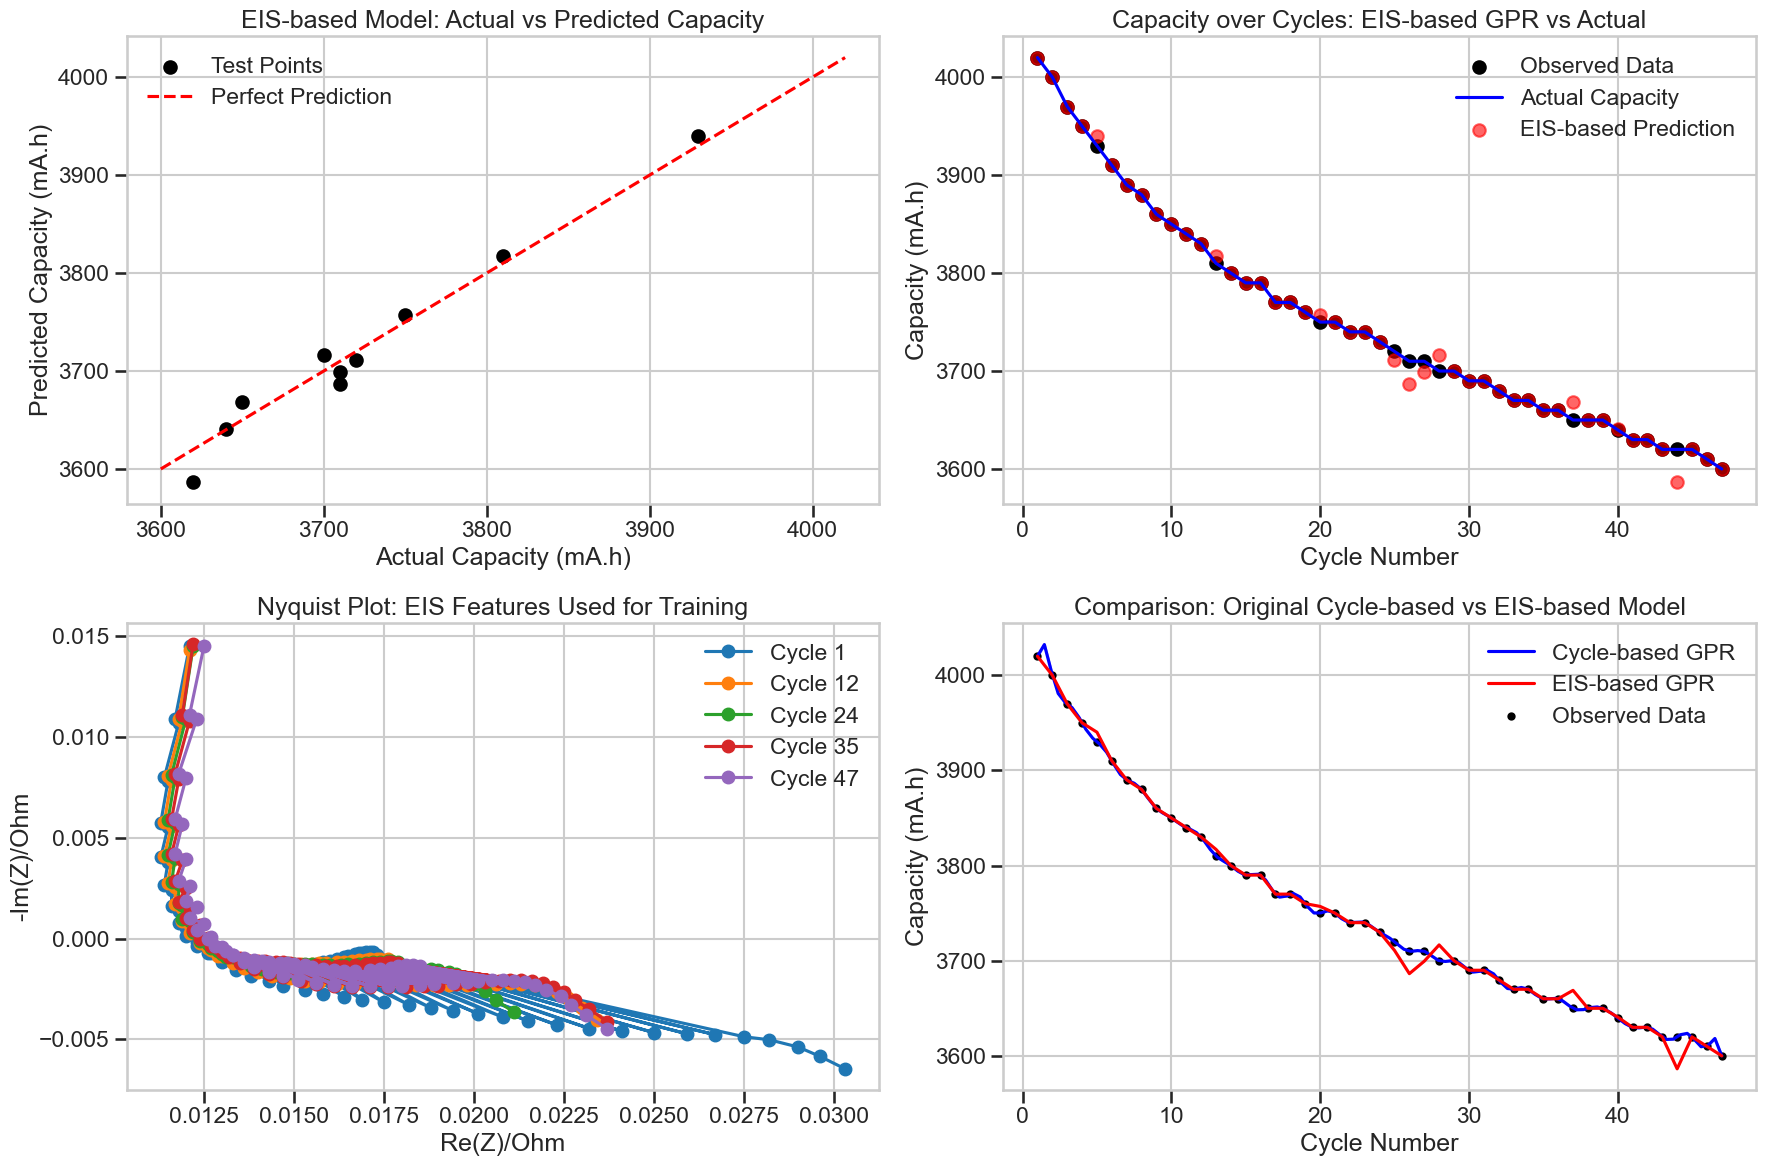

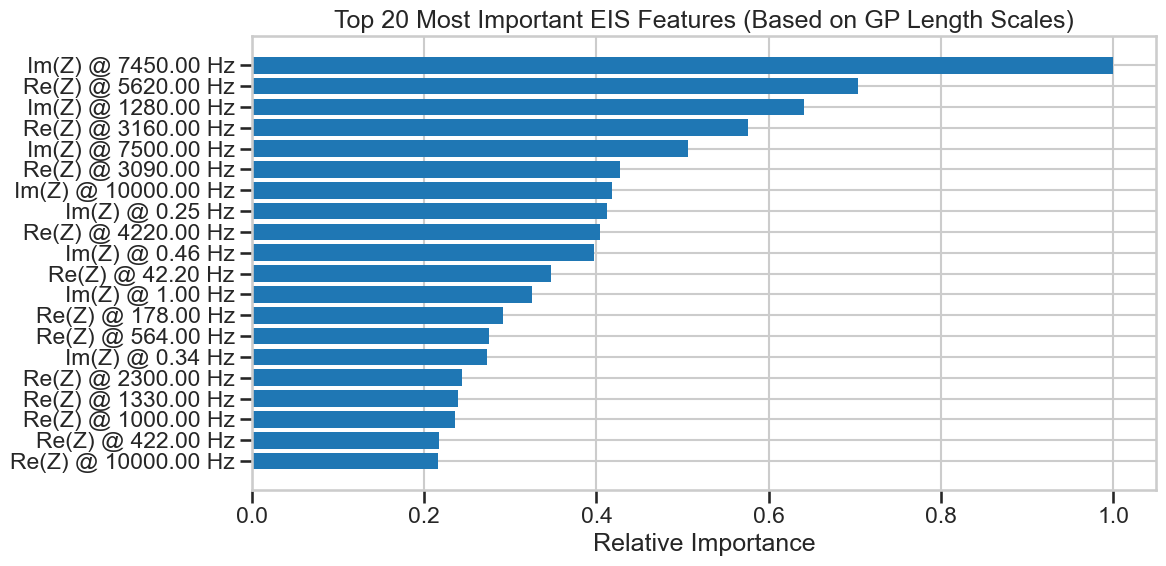

Model comparison:
1. Original approach: Using only cycle numbers as features
2. New approach: Using EIS data (Re(Z)/Ohm and Im(Z)/Ohm) at multiple frequencies as features

Key changes:
- Each feature vector now contains impedance values at different frequencies
- The model can learn patterns in the impedance spectra that correlate with capacity fade
- Added visualization of which frequencies/impedance components are most predictive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("/Users/apple/Desktop/eis-ml/data/03-06-24/A8.csv")

# Data preprocessing
df = df.dropna()  # Drop empty rows
df = df.loc[(df['cycle number'] != 0)].copy()  # Drop 0th cycle
df.rename(columns={'Unnamed: 0': 'Im(Z)/Ohm'}, inplace=True)  # Rename to Imaginary impedance

# Filter EIS data to relevant frequency range
df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]

# Ordering by cycle and frequency
df = df.sort_values(by=['cycle number', 'freq/Hz'])

# Get unique frequencies to ensure consistent feature space
unique_freqs = df['freq/Hz'].unique()
print(f"Number of unique frequencies: {len(unique_freqs)}")

# Create a feature matrix for each cycle using impedance data at specific frequencies
all_cycles = df['cycle number'].unique()
X_features = []
y_capacity = []
valid_cycles = []

# Store impedance values for visualization
impedance_data = {}

for cycle in all_cycles:
    cycle_data = df[df['cycle number'] == cycle]
    capacity = cycle_data['Capacity/mA.h'].values[0]
    cycle_features = []

    impedance_data[cycle] = {
        'freq': [],
        'Re(Z)': [],
        'Im(Z)': []
    }

    for freq in unique_freqs:
        freq_data = cycle_data[cycle_data['freq/Hz'] == freq]
        if len(freq_data) == 0:
            cycle_features.extend([np.nan, np.nan])
            continue

        real_z = freq_data['Re(Z)/Ohm'].values[0]
        imag_z = freq_data['Im(Z)/Ohm'].values[0]

        impedance_data[cycle]['freq'].append(freq)
        impedance_data[cycle]['Re(Z)'].append(real_z)
        impedance_data[cycle]['Im(Z)'].append(imag_z)

        cycle_features.extend([real_z, imag_z])

    if not np.isnan(np.sum(cycle_features)):
        X_features.append(cycle_features)
        y_capacity.append(capacity)
        valid_cycles.append(cycle)

# Convert to numpy arrays
X_features = np.array(X_features)
y_capacity = np.array(y_capacity)
valid_cycles = np.array(valid_cycles)

print(f"Feature matrix shape: {X_features.shape}")
print(f"Target vector shape: {y_capacity.shape}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_capacity, test_size=0.2, random_state=42
)

# Define and train the Gaussian Process model
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X_train.shape[1]), length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)
gp.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = gp.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"R² score: {r2:.4f}")

# Save the model and scaler
joblib.dump(gp, 'gpr_battery_eis_model.joblib')
joblib.dump(scaler, 'eis_scaler.joblib')

# Create a figure with multiple subplots to show the changes clearly
plt.figure(figsize=(18, 12))

# 1. Plot actual vs predicted capacity
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred_test, c='k', label='Test Points')
plt.plot([y_capacity.min(), y_capacity.max()], [y_capacity.min(), y_capacity.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Capacity (mA.h)')
plt.ylabel('Predicted Capacity (mA.h)')
plt.title('EIS-based Model: Actual vs Predicted Capacity')
plt.legend()
plt.grid(True)

# 2. Plot capacity vs cycle number
plt.subplot(2, 2, 2)
plt.scatter(valid_cycles, y_capacity, c='k', label='Observed Data')

# Sort cycles for smooth line
sorted_indices = np.argsort(valid_cycles)
sorted_cycles = valid_cycles[sorted_indices]
sorted_capacity = y_capacity[sorted_indices]

plt.plot(sorted_cycles, sorted_capacity, 'b-', label='Actual Capacity')

# Get predictions for all cycles
all_features_scaled = scaler.transform(X_features)
all_predictions = gp.predict(all_features_scaled)

plt.scatter(valid_cycles, all_predictions, c='r', label='EIS-based Prediction', alpha=0.6)
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (mA.h)')
plt.title('Capacity over Cycles: EIS-based GPR vs Actual')
plt.legend()
plt.grid(True)

# 3. Plot Nyquist plot (Re(Z) vs -Im(Z)) for selected cycles
plt.subplot(2, 2, 3)
selected_cycles = np.linspace(min(valid_cycles), max(valid_cycles), 5, dtype=int)
for cycle in selected_cycles:
    if cycle in impedance_data:
        plt.plot(impedance_data[cycle]['Re(Z)'],
                 [-z for z in impedance_data[cycle]['Im(Z)']],
                 'o-', label=f"Cycle {cycle}")
plt.xlabel('Re(Z)/Ohm')
plt.ylabel('-Im(Z)/Ohm')
plt.title('Nyquist Plot: EIS Features Used for Training')
plt.legend()
plt.grid(True)

# 4. Compare original model (cycle-based) with EIS-based model
plt.subplot(2, 2, 4)

X_cycles = sorted_cycles.reshape(-1, 1)
y_cycles = sorted_capacity

kernel_original = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp_original = GaussianProcessRegressor(kernel=kernel_original, n_restarts_optimizer=10)
gp_original.fit(X_cycles, y_cycles)

X_pred = np.linspace(min(valid_cycles), max(valid_cycles), 100).reshape(-1, 1)
y_pred_original, sigma_original = gp_original.predict(X_pred, return_std=True)

plt.plot(X_pred, y_pred_original, 'b-', label='Cycle-based GPR')
plt.fill_between(X_pred.ravel(),
                 y_pred_original - 1.96 * sigma_original,
                 y_pred_original + 1.96 * sigma_original,
                 alpha=0.2, color='blue')

plt.plot(sorted_cycles,
         all_predictions[sorted_indices],
         'r-', label='EIS-based GPR')
plt.scatter(valid_cycles, y_capacity, c='k', s=20, label='Observed Data')

plt.xlabel('Cycle Number')
plt.ylabel('Capacity (mA.h)')
plt.title('Comparison: Original Cycle-based vs EIS-based Model')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('eis_ml_comparison.png', dpi=300)
plt.show()

# 5. Feature importance visualization
plt.figure(figsize=(12, 6))

if hasattr(gp.kernel_, 'k2') and hasattr(gp.kernel_.k2, 'length_scale'):
    length_scales = gp.kernel_.k2.length_scale
    feature_labels = []
    importance_values = 1.0 / length_scales
    importance_values = importance_values / np.max(importance_values)

    for i in range(len(length_scales)):
        freq_idx = i // 2
        imp_type = "Re(Z)" if i % 2 == 0 else "Im(Z)"
        if freq_idx < len(unique_freqs):
            feature_labels.append(f"{imp_type} @ {unique_freqs[freq_idx]:.2f} Hz")

    sorted_indices = np.argsort(importance_values)[-20:]

    plt.barh([feature_labels[i] for i in sorted_indices],
             [importance_values[i] for i in sorted_indices])
    plt.xlabel('Relative Importance')
    plt.title('Top 20 Most Important EIS Features (Based on GP Length Scales)')
    plt.tight_layout()
    plt.savefig('eis_feature_importance.png', dpi=300)
    plt.show()

print("Model comparison:")
print("1. Original approach: Using only cycle numbers as features")
print("2. New approach: Using EIS data (Re(Z)/Ohm and Im(Z)/Ohm) at multiple frequencies as features")
print("\nKey changes:")
print("- Each feature vector now contains impedance values at different frequencies")
print("- The model can learn patterns in the impedance spectra that correlate with capacity fade")
print("- Added visualization of which frequencies/impedance components are most predictive")
